In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from src.load_data import *
from src.preprocess import *

In [19]:
filepath = "data/GlobalWeatherRepository.csv"
df = load_raw_data(filepath)

df = standardize_columns(df)

df = parse_datetime_local(df)

df = parse_datetime_unix(df)

df = drop_duplicates(df)

df_original = df.copy()

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_pm2.5,air_quality_pm10,air_quality_us_epa_index,air_quality_gb_defra_index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-16 08:45:00+00:00,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,2024-05-16 08:45:00+00:00,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,2024-05-16 08:45:00+00:00,2024-05-16 09:45:00,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,2024-05-16 08:45:00+00:00,2024-05-16 10:45:00,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,2024-05-16 08:45:00+00:00,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [3]:
# Daily series for ONE city (temperature)

country = "Canada"
city = "Ottawa"

df_city = df[(df["country"] == country) & (df["location_name"] == city)].copy()

# daily bucket
df_city["date"] = df_city["last_updated"].dt.floor("D")   # using last_updated feature

# daily average temperature
ts_temp = (
    df_city.groupby("date")["temperature_celsius"]
          .mean()
          .sort_index()
)

# create full daily index
full_idx = pd.date_range(ts_temp.index.min(), ts_temp.index.max(), freq="D")
ts_temp = ts_temp.reindex(full_idx)

# fill missing days (temperature is continuous → interpolate is OK)
ts_temp = ts_temp.interpolate(limit_direction="both")


ts_temp.head()

2024-05-16    14.0
2024-05-17    20.0
2024-05-18    18.0
2024-05-19    18.0
2024-05-20    23.0
Freq: D, Name: temperature_celsius, dtype: float64

In [4]:
# Train-test split (time-based)

n = len(ts_temp)
test_size = int(0.2 * n)

train = ts_temp.iloc[:-test_size]
test  = ts_temp.iloc[-test_size:]

len(train), len(test)

(515, 128)

In [5]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

def make_weights_from_errors(err_dict, eps=1e-8):
    # inverse-error weights
    inv = {k: 1.0 / (v + eps) for k, v in err_dict.items()}
    s = sum(inv.values())
    return {k: inv[k] / s for k in inv}

In [6]:
# ---- daily multivariate table aligned to ts_temp index ----
df_city = df[(df["country"] == country) & (df["location_name"] == city)].copy()
df_city["date"] = df_city["last_updated"].dt.floor("D")

agg_map = {
    "temperature_celsius": "mean",
    "humidity": "mean",
    "pressure_mb": "mean",
    "wind_kph": "mean",
    "gust_kph": "mean",
    "cloud": "mean",
    "precip_mm": "sum",
    "uv_index": "mean",
    "visibility_km": "mean",
    "latitude": "first",
    "longitude": "first",
    "condition_text": lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[-1],
}

daily = df_city.groupby("date").agg(agg_map).sort_index()
daily = daily.reindex(ts_temp.index)

# fill
daily["temperature_celsius"] = daily["temperature_celsius"].interpolate(limit_direction="both")
for col in ["humidity","pressure_mb","wind_kph","gust_kph","cloud","precip_mm","uv_index","visibility_km"]:
    daily[col] = daily[col].interpolate(limit_direction="both")

daily["latitude"] = daily["latitude"].ffill().bfill()
daily["longitude"] = daily["longitude"].ffill().bfill()

daily["condition_text"] = daily["condition_text"].ffill().bfill()
daily["condition_text"] = daily["condition_text"].astype("category").cat.codes

# target = same-day temp
daily["y"] = ts_temp.values

# calendar features
daily["dayofweek"] = daily.index.dayofweek
daily["month"] = daily.index.month
daily["dayofyear"] = daily.index.dayofyear

# lag + rolling features
LAGS = [1, 2, 3, 7, 14]
for l in LAGS:
    daily[f"temp_lag_{l}"] = daily["y"].shift(l)

exo_cols = ["humidity","pressure_mb","wind_kph","gust_kph","cloud","precip_mm","uv_index","visibility_km"]
for col in exo_cols:
    for l in LAGS:
        daily[f"{col}_lag_{l}"] = daily[col].shift(l)

daily["temp_roll_mean_7"] = daily["y"].shift(1).rolling(7).mean()
daily["temp_roll_std_7"]  = daily["y"].shift(1).rolling(7).std()

data_ml = daily.dropna().copy()

# split boundary EXACTLY from your train/test split
split_date = train.index[-1]
train_ml = data_ml.loc[data_ml.index <= split_date].copy()
test_ml  = data_ml.loc[data_ml.index >  split_date].copy()

X_train_full = train_ml.drop(columns=["y"])
y_train_full = train_ml["y"]
X_test = test_ml.drop(columns=["y"])
y_test = test_ml["y"]

# univariate feature subset (temp-only + calendar)
uni_cols = [c for c in X_train_full.columns if c.startswith("temp_") or c in ["dayofweek","month","dayofyear"]]
X_train_uni_full = X_train_full[uni_cols]
X_test_uni = X_test[uni_cols]

In [18]:
# validation = last 20% of TRAIN (time-based)
val_frac = 0.2
val_start_idx = int(len(train_ml) * (1 - val_frac))

train_sub = train_ml.iloc[:val_start_idx]
val_sub   = train_ml.iloc[val_start_idx:]

X_tr = train_sub.drop(columns=["y"])
y_tr = train_sub["y"]
X_val = val_sub.drop(columns=["y"])
y_val = val_sub["y"]

X_tr_uni = X_tr[uni_cols]
X_val_uni = X_val[uni_cols]

print(X_tr_uni.shape)

(400, 10)


In [8]:
# --- build univariate train_sub/val_sub series aligned to ts_temp ---
ts_u = ts_temp.copy()
train_u = train
test_u = test

# match train_sub/val_sub dates for univariate series:
train_sub_u = ts_u.loc[train_sub.index.min():train_sub.index.max()]
val_sub_u   = ts_u.loc[val_sub.index.min():val_sub.index.max()]

# ETS (val)
ets_val = ExponentialSmoothing(
    train_sub_u, trend="add", seasonal=None, initialization_method="estimated"
).fit(optimized=True)
pred_ets_val = pd.Series(ets_val.forecast(len(val_sub_u)), index=val_sub_u.index)

# SARIMA (val)
sarima_val = auto_arima(
    train_sub_u, seasonal=True, m=7, trace=False,
    error_action="ignore", suppress_warnings=True, stepwise=True
)
pred_sarima_val = pd.Series(sarima_val.predict(n_periods=len(val_sub_u)), index=val_sub_u.index)

# XGB-Uni (val)
xgb_uni = XGBRegressor(
    n_estimators=2000, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_uni.fit(X_tr_uni, y_tr)
pred_xgb_uni_val = pd.Series(xgb_uni.predict(X_val_uni), index=y_val.index)

# --- compute validation RMSEs for weights ---
uni_val_err = {
    "ETS": rmse(val_sub_u.loc[pred_ets_val.index], pred_ets_val),
    "SARIMA": rmse(val_sub_u.loc[pred_sarima_val.index], pred_sarima_val),
    "XGB-Uni": rmse(y_val.loc[pred_xgb_uni_val.index], pred_xgb_uni_val),
}
uni_w = make_weights_from_errors(uni_val_err)
print("Univariate ensemble weights:", uni_w)

# --- refit each univariate model on FULL train and predict test ---
ets_full = ExponentialSmoothing(
    train_u, trend="add", seasonal=None, initialization_method="estimated"
).fit(optimized=True)
pred_ets_test = pd.Series(ets_full.forecast(len(test_u)), index=test_u.index)

sarima_full = auto_arima(
    train_u, seasonal=True, m=7, trace=False,
    error_action="ignore", suppress_warnings=True, stepwise=True
)
pred_sarima_test = pd.Series(sarima_full.predict(n_periods=len(test_u)), index=test_u.index)

# refit XGB-Uni on full ML train
xgb_uni_full = XGBRegressor(
    n_estimators=2000, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_uni_full.fit(X_train_uni_full, y_train_full)
pred_xgb_uni_test = pd.Series(xgb_uni_full.predict(X_test_uni), index=y_test.index)

# Univariate ensemble on the test window 
# XGB-Uni is only defined on y_test.index (because of lags). So ensemble uses overlap only.
common_uni_idx = test_u.index.intersection(pred_xgb_uni_test.index)

ens_uni = (
    uni_w["ETS"]   * pred_ets_test.loc[common_uni_idx] +
    uni_w["SARIMA"]* pred_sarima_test.loc[common_uni_idx] +
    uni_w["XGB-Uni"]*pred_xgb_uni_test.loc[common_uni_idx]
)

Univariate ensemble weights: {'ETS': np.float64(0.29764395852591985), 'SARIMA': np.float64(0.2427385020899229), 'XGB-Uni': np.float64(0.4596175393841572)}


In [ ]:
# Univariate comparison table (singles vs ensemble)
rows = []
y_true_uni = ts_temp.loc[common_uni_idx]

uni_preds = {
    "ETS": pred_ets_test.loc[common_uni_idx],
    "SARIMA": pred_sarima_test.loc[common_uni_idx],
    "XGB-Uni": pred_xgb_uni_test.loc[common_uni_idx],
    "ENS-Uni": ens_uni.loc[common_uni_idx],
}

for name, p in uni_preds.items():
    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_true_uni, p),
        "RMSE": rmse(y_true_uni, p),
        "sMAPE(%)": smape(y_true_uni, p),
    })

uni_results = pd.DataFrame(rows).sort_values("RMSE")
display(uni_results)

In [ ]:
# XGB-MV (val)
xgb_mv = XGBRegressor(
    n_estimators=2000, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_mv.fit(X_tr, y_tr)
pred_xgb_mv_val = pd.Series(xgb_mv.predict(X_val), index=y_val.index)

# LGBM-MV (val)
lgbm_mv = LGBMRegressor(
    n_estimators=5000, learning_rate=0.02, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
lgbm_mv.fit(X_tr, y_tr)
pred_lgbm_mv_val = pd.Series(lgbm_mv.predict(X_val), index=y_val.index)

mv_val_err = {
    "XGB-MV": rmse(y_val, pred_xgb_mv_val),
    "LGBM-MV": rmse(y_val, pred_lgbm_mv_val),
}
mv_w = make_weights_from_errors(mv_val_err)
print("Multivariate ensemble weights:", mv_w)

# refit on full train and predict test
xgb_mv_full = XGBRegressor(
    n_estimators=2000, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_mv_full.fit(X_train_full, y_train_full)
pred_xgb_mv_test = pd.Series(xgb_mv_full.predict(X_test), index=y_test.index)

lgbm_mv_full = LGBMRegressor(
    n_estimators=5000, learning_rate=0.02, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
lgbm_mv_full.fit(X_train_full, y_train_full)
pred_lgbm_mv_test = pd.Series(lgbm_mv_full.predict(X_test), index=y_test.index)

# multivariate ensemble
ens_mv = (
    mv_w["XGB-MV"] * pred_xgb_mv_test +
    mv_w["LGBM-MV"] * pred_lgbm_mv_test
)

In [ ]:
# Multivariate comparison table (singles vs ensemble)

rows = []
y_true_mv = y_test

mv_preds = {
    "XGB-MV": pred_xgb_mv_test,
    "LGBM-MV": pred_lgbm_mv_test,
    "ENS-MV": ens_mv,
}

for name, p in mv_preds.items():
    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_true_mv, p),
        "RMSE": rmse(y_true_mv, p),
        "sMAPE(%)": smape(y_true_mv, p),
    })

mv_results = pd.DataFrame(rows).sort_values("RMSE")
display(mv_results)

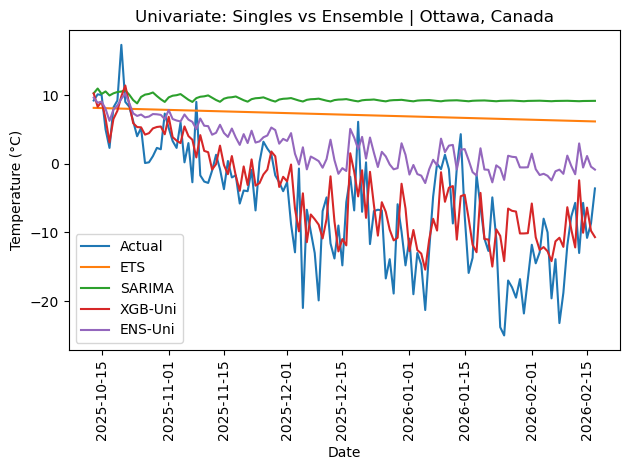

In [16]:
plt.figure()
plt.plot(ts_temp.loc[common_uni_idx].index, ts_temp.loc[common_uni_idx].values, label="Actual")
plt.plot(pred_ets_test.loc[common_uni_idx].index, pred_ets_test.loc[common_uni_idx].values, label="ETS")
plt.plot(pred_sarima_test.loc[common_uni_idx].index, pred_sarima_test.loc[common_uni_idx].values, label="SARIMA")
plt.plot(pred_xgb_uni_test.loc[common_uni_idx].index, pred_xgb_uni_test.loc[common_uni_idx].values, label="XGB-Uni")
plt.plot(ens_uni.loc[common_uni_idx].index, ens_uni.loc[common_uni_idx].values, label="ENS-Uni")
plt.title(f"Univariate: Singles vs Ensemble | {city}, {country}")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
#plt.savefig("univariate_result.png")
plt.show()

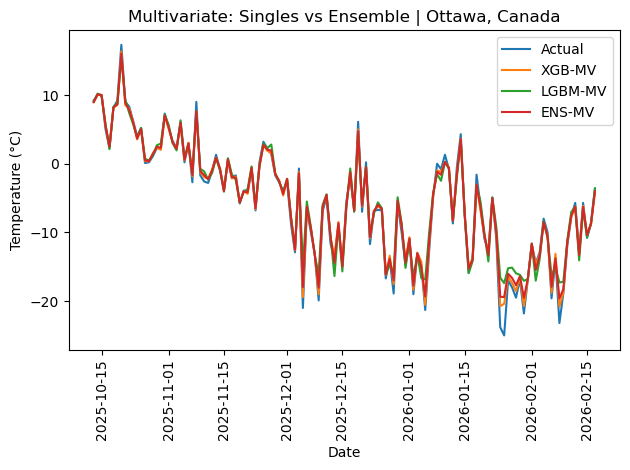

In [17]:
plt.figure()
plt.plot(y_test.index, y_test.values, label="Actual")
plt.plot(pred_xgb_mv_test.index, pred_xgb_mv_test.values, label="XGB-MV")
plt.plot(pred_lgbm_mv_test.index, pred_lgbm_mv_test.values, label="LGBM-MV")
plt.plot(ens_mv.index, ens_mv.values, label="ENS-MV")
plt.title(f"Multivariate: Singles vs Ensemble | {city}, {country}")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
#plt.savefig("multivariate_result.png")
plt.show()